# Satellite Image — Auto Ship Detector & Cropper
Detecta barcos **automáticamente** usando visión por computadora (OpenCV).
Funciona con ambas imágenes de ejemplo sin coordenadas manuales.

| Celda | Descripción |
|---|---|
| 1 | Instalar dependencias |
| 2 | Imports |
| 3 | Subir imagen y cargarla |
| 4 | Visualizar imagen original |
| 5 | **Detección automática** de barcos |
| 6 | Ajuste fino con sliders interactivos |
| 7 | Cropear y guardar barcos |
| 8 | Redimensionar a 80×80 para ML |

## 1 — Instalar dependencias

In [ ]:
#!pip install opencv-python-headless Pillow matplotlib ipywidgets scikit-image --quiet
#print('Dependencias listas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 34.9 MB/s eta 0:00:00
Dependencias listas


##2 — Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ipywidgets import interact, IntSlider, FloatSlider
import os, glob

print('Imports OK')

Imports OK


##3 — Subir imagen y cargarla
Ejecutá **3a** para subir desde tu PC, o **3b** si ya están en `/content/sample_data`.

In [ ]:
# ── Celda 3a: Subir imágenes desde tu PC ──────────────────────
#from google.colab import files

#print('Seleccioná una o ambas imágenes satelitales...')
#uploaded = files.upload()

#os.makedirs('/content/sample_data', exist_ok=True)
#for nombre, contenido in uploaded.items():
#    ruta = f'/content/sample_data/{nombre}'
#    with open(ruta, 'wb') as f:
#        f.write(contenido)
#    print(f'   Guardado → {ruta}')

Seleccioná una o ambas imágenes satelitales...


Saving 2523523552-1.jpg to 2523523552-1.jpg
   Guardado → /content/sample_data/2523523552-1.jpg


 Imágenes encontradas: 512


 Imagen cargada : 20181030_023205_1018_3B_Visual_9_png_jpg.rf.258385542b9b19a618f4379e57caa472.jpg
   Tamaño          : 640 × 640 px


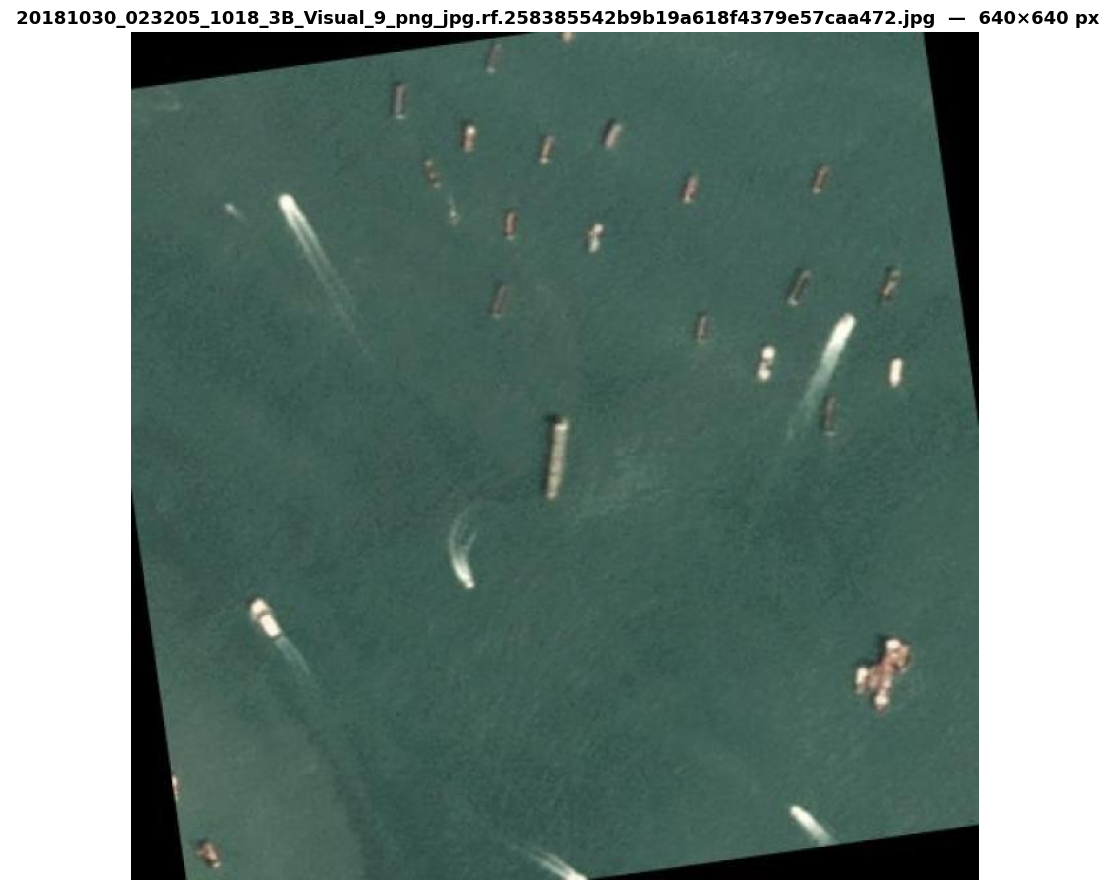

In [36]:
# ── Celda 3b: Seleccionar imagen ──────────────────────────────
#  Cambiá INDICE:
#     0 → primera imagen encontrada
#     1 → segunda imagen encontrada  (ej: la teal con nubes)
# ─────────────────────────────────────────────────────────────
INDICE = 78

CARPETA = 'datasets/roboflow_annotated/valid/images'
imagenes_disponibles = sorted(
    glob.glob(f'{CARPETA}/**/*.png', recursive=True) +
    glob.glob(f'{CARPETA}/**/*.jpg', recursive=True) +
    glob.glob(f'{CARPETA}/**/*.jpeg', recursive=True)
)

if not imagenes_disponibles:
    raise FileNotFoundError(f' No hay imágenes en {CARPETA}. Ejecutá primero la celda 3a.')

print(f' Imágenes encontradas: {len(imagenes_disponibles)}\n')
#for i, ruta in enumerate(imagenes_disponibles):
#    print(f'   [{i}]  {os.path.basename(ruta)}')

ruta_imagen  = imagenes_disponibles[INDICE]
NOMBRE_IMG   = os.path.basename(ruta_imagen)
imagen_pil   = Image.open(ruta_imagen).convert('RGB')
IMG_W, IMG_H = imagen_pil.size
img_np       = np.array(imagen_pil)   # (H, W, 3) uint8 RGB

print(f'\n Imagen cargada : {NOMBRE_IMG}')
print(f'   Tamaño          : {IMG_W} × {IMG_H} px')

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(img_np)
ax.set_title(f" {NOMBRE_IMG}  —  {IMG_W}×{IMG_H} px", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

##  Celda 4 — Visualizar imagen original

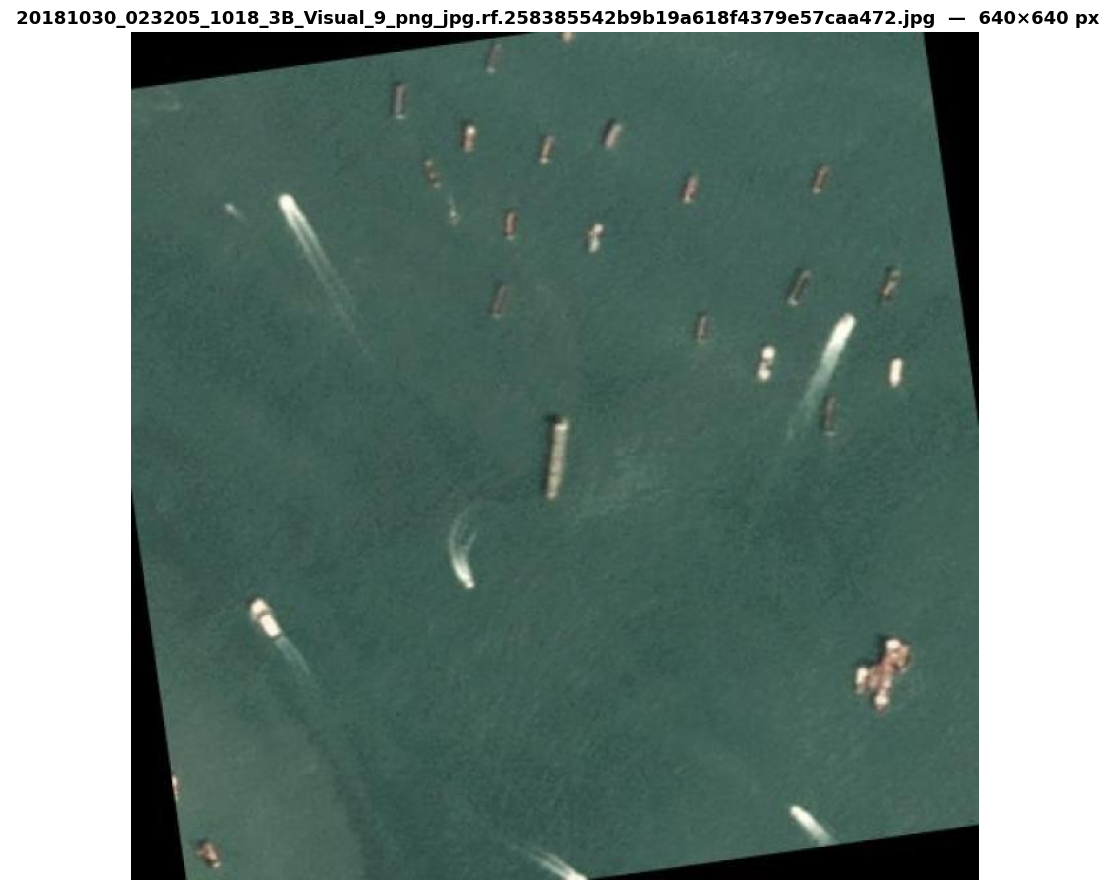

In [37]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(img_np)
ax.set_title(f' {NOMBRE_IMG}  —  {IMG_W}×{IMG_H} px',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

##  Celda 5 — Detección automática de barcos

**Estrategia multi-canal:**
1. Canal **V** (brillo HSV) → detecta objetos más brillantes que el agua
2. Canal **Saturación** → detecta barcos coloridos (rojo/naranja/blanco)
3. Morfología para limpiar ruido
4. Filtro por **área** y **relación de aspecto** → los barcos son elongados

>  Los parámetros se ajustan automáticamente según el fondo de la imagen.

In [38]:
# ═══════════════════════════════════════════════════════════════
#  FUNCIÓN PRINCIPAL DE DETECCIÓN
# ═══════════════════════════════════════════════════════════════

def detectar_barcos(
    img_rgb,
    brillo_percentil   = 90,   # umbral de brillo (% de píxeles a ignorar)
    min_area           = 60,   # área mínima en px² para ser barco
    max_area           = 4000, # área máxima (filtra nubes y artefactos)
    min_aspecto        = 1.8,  # relación largo/ancho mínima (barcos = elongados)
    max_aspecto        = 18.0, # relación largo/ancho máxima
    usar_sat           = True, # usar canal de saturación además de brillo
    kernel_size        = 2,    # tamaño kernel morfológico
):
    """
    Detecta barcos en imagen satelital RGB.

    Returns
    -------
    barcos  : lista de dicts con 'id', 'bbox'=(x,y,w,h), 'label', 'area', 'aspecto'
    mascara : ndarray uint8 — máscara binaria usada para la detección
    """
    # 1. Convertir a HSV
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    hsv     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    v       = hsv[:, :, 2]   # brillo
    s       = hsv[:, :, 1]   # saturación

    # 2. Máscara de brillo
    umbral_v  = np.percentile(v, brillo_percentil)
    mask_v    = (v > umbral_v).astype(np.uint8) * 255

    # 3. Máscara de saturación (barcos coloridos)
    if usar_sat:
        umbral_s = np.percentile(s, 92)
        mask_s   = (s > umbral_s).astype(np.uint8) * 255
        mascara  = cv2.bitwise_or(mask_v, mask_s)
    else:
        mascara  = mask_v

    # 4. Morfología
    k  = np.ones((kernel_size, kernel_size), np.uint8)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN,  k)  # quita ruido
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, k)  # cierra huecos

    # 5. Contornos
    cnts, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    barcos = []
    for cnt in cnts:
        area = cv2.contourArea(cnt)
        if not (min_area <= area <= max_area):
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        lado_mayor = max(w, h)
        lado_menor = max(min(w, h), 1)
        aspecto    = lado_mayor / lado_menor

        if not (min_aspecto <= aspecto <= max_aspecto):
            continue

        if lado_mayor < 8:   # demasiado pequeño
            continue

        barcos.append({
            'bbox'   : (x, y, w, h),
            'area'   : round(area, 1),
            'aspecto': round(aspecto, 2),
        })

    # 6. Ordenar por área descendente y numerar
    barcos.sort(key=lambda b: -b['area'])
    for i, b in enumerate(barcos):
        b['id']    = i + 1
        b['label'] = f'Barco {i + 1}'

    return barcos, mascara


# ═══════════════════════════════════════════════════════════════
#  PARÁMETROS AUTOMÁTICOS SEGÚN EL FONDO
# ═══════════════════════════════════════════════════════════════

def parametros_por_imagen(img_rgb):
    """
    Estima parámetros de detección analizando el fondo de la imagen.
    - Fondo oscuro (agua azul profunda) → umbral de brillo alto
    - Fondo con nubes → max_area más restrictiva, sin saturación
    """
    brillo_medio = np.mean(img_rgb)
    desv         = np.std(img_rgb)

    # Imagen 1: fondo muy oscuro (azul profundo)
    if brillo_medio < 80:
        return dict(brillo_percentil=88, min_area=50, max_area=5000,
                    min_aspecto=1.8, max_aspecto=18, usar_sat=True,  kernel_size=2)
    # Imagen 2: fondo teal más claro, con nubes
    elif brillo_medio < 140:
        return dict(brillo_percentil=93, min_area=80, max_area=2000,
                    min_aspecto=2.0, max_aspecto=14, usar_sat=False, kernel_size=2)
    # Imagen muy clara (alta reflexión)
    else:
        return dict(brillo_percentil=95, min_area=60, max_area=3000,
                    min_aspecto=1.8, max_aspecto=16, usar_sat=False, kernel_size=3)


# ── Ejecutar detección ────────────────────────────────────────
params = parametros_por_imagen(img_np)
print(f'Brillo medio de la imagen : {np.mean(img_np):.1f}')
print(f' Parámetros seleccionados  : {params}\n')

BARCOS, MASCARA = detectar_barcos(img_np, **params)

print(f' Barcos detectados: {len(BARCOS)}')
for b in BARCOS:
    x, y, w, h = b['bbox']
    print(f"   {b['label']:10s}  bbox=({x:4d},{y:4d},{w:3d},{h:3d})  "
          f"área={b['area']:7.0f}px²  aspecto={b['aspecto']:.2f}")

Brillo medio de la imagen : 79.4
 Parámetros seleccionados  : {'brillo_percentil': 88, 'min_area': 50, 'max_area': 5000, 'min_aspecto': 1.8, 'max_aspecto': 18, 'usar_sat': True, 'kernel_size': 2}

 Barcos detectados: 27
   Barco 1     bbox=( 327,   0,184, 55)  área=   3333px²  aspecto=3.35
   Barco 2     bbox=( 365, 571,235, 69)  área=   2522px²  aspecto=3.41
   Barco 3     bbox=( 564,   0, 76,272)  área=   2500px²  aspecto=3.58
   Barco 4     bbox=( 193,   0, 97, 18)  área=    762px²  aspecto=5.39
   Barco 5     bbox=( 240, 362, 23, 62)  área=    682px²  aspecto=2.70
   Barco 6     bbox=( 316, 292, 18, 64)  área=    594px²  aspecto=3.56
   Barco 7     bbox=(  81,  17,110, 16)  área=    578px²  aspecto=6.88
   Barco 8     bbox=( 381, 462, 51, 27)  área=    502px²  aspecto=1.89
   Barco 9     bbox=( 302, 617, 72, 23)  área=    446px²  aspecto=3.13
   Barco 10    bbox=(   0, 348, 10, 55)  área=    262px²  aspecto=5.50
   Barco 11    bbox=( 573, 248, 15, 29)  área=    246px²  aspecto=1.93

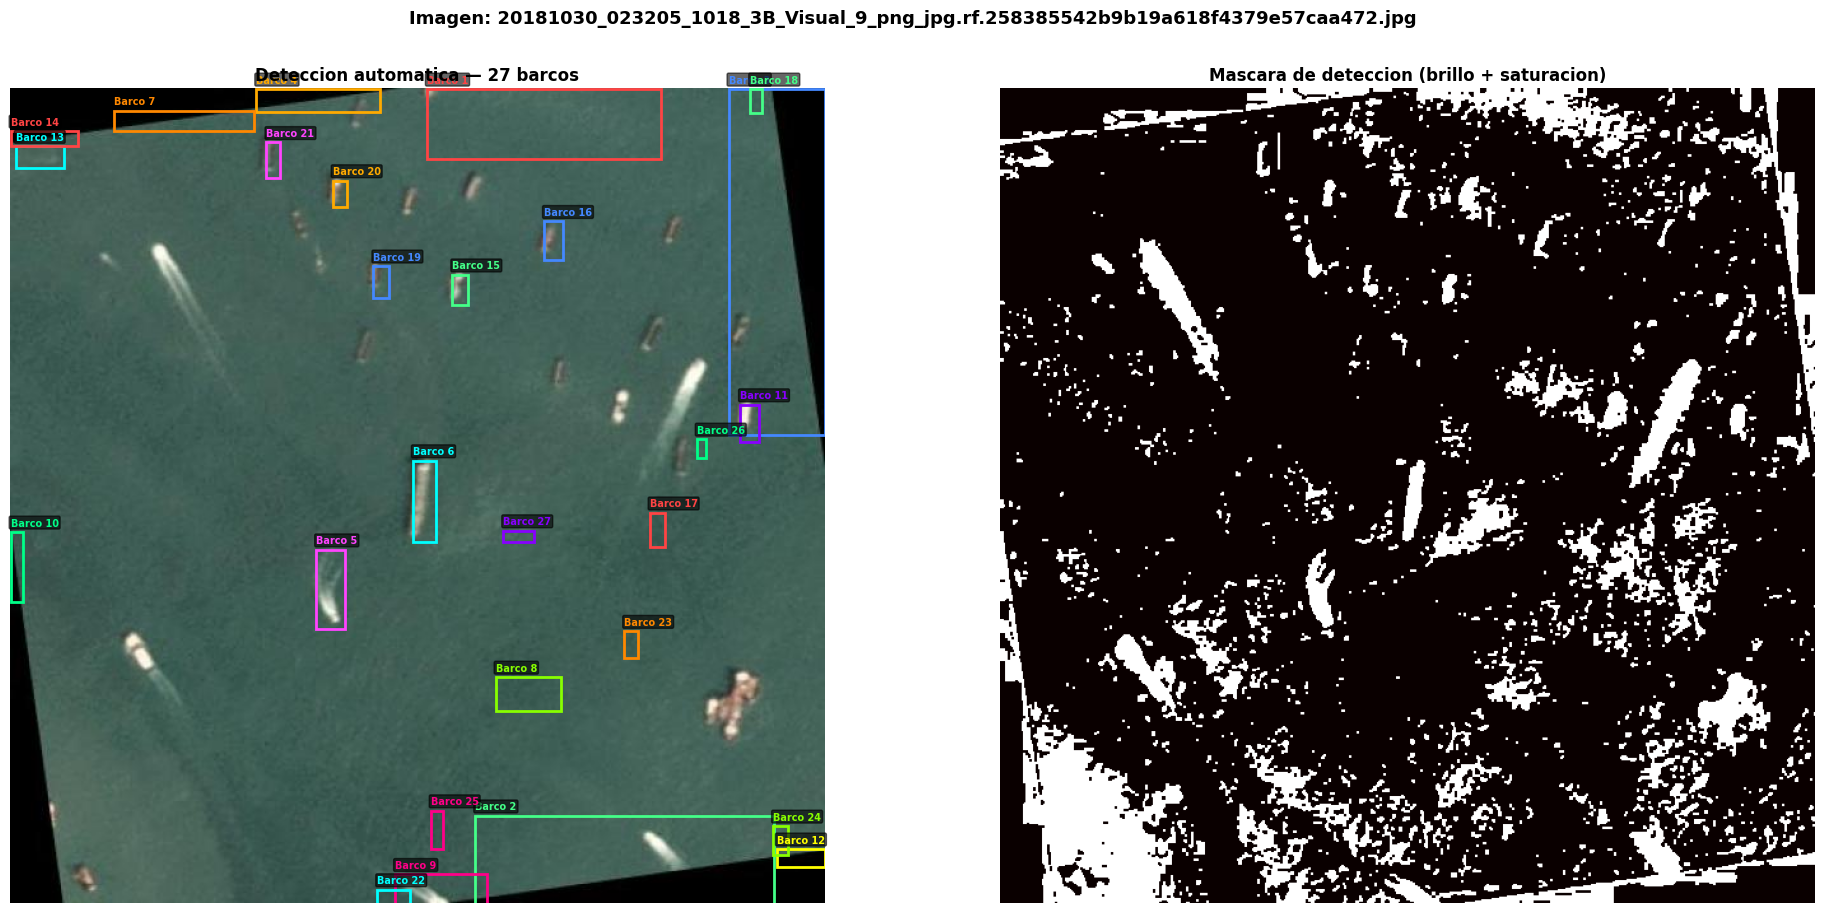

In [39]:
# ── Visualización: imagen + máscara + bounding boxes ──────────
COLORES = ['#FF4444','#44FF88','#4488FF','#FFAA00','#FF44FF',
           '#00FFFF','#FF8800','#88FF00','#FF0088','#00FF88',
           '#8800FF','#FFFF00','#00FFFF','#FF4444','#44FF88','#4488FF']

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Panel izquierdo: imagen con bounding boxes
axes[0].imshow(img_np)
for i, barco in enumerate(BARCOS):
    x, y, w, h = barco['bbox']
    color = COLORES[i % len(COLORES)]
    rect  = patches.Rectangle((x, y), w, h,
                                linewidth=2, edgecolor=color, facecolor='none')
    axes[0].add_patch(rect)
    axes[0].text(x, y - 5, barco['label'], color=color, fontsize=7,
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))
axes[0].set_title(f'Deteccion automatica — {len(BARCOS)} barcos', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Panel derecho: máscara binaria
axes[1].imshow(MASCARA, cmap='hot')
axes[1].set_title('Mascara de deteccion (brillo + saturacion)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle(f'Imagen: {NOMBRE_IMG}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##  Celda 6 — Ajuste fino interactivo
Si la detección no es perfecta, mové los sliders para refinar los parámetros.

In [ ]:
# ── Sliders interactivos para ajustar la detección ───────────

def actualizar_deteccion(
    brillo_percentil,
    min_area,
    max_area,
    min_aspecto,
    max_aspecto,
):
    global BARCOS, MASCARA

    BARCOS, MASCARA = detectar_barcos(
        img_np,
        brillo_percentil = brillo_percentil,
        min_area         = min_area,
        max_area         = max_area,
        min_aspecto      = min_aspecto,
        max_aspecto      = max_aspecto,
        usar_sat         = True,
    )

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    axes[0].imshow(img_np)
    for i, barco in enumerate(BARCOS):
        x, y, w, h = barco['bbox']
        color = COLORES[i % len(COLORES)]
        rect  = patches.Rectangle((x, y), w, h,
                                    linewidth=2, edgecolor=color, facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x, y - 5, barco['label'], color=color, fontsize=7,
                     fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))
    axes[0].set_title(f'{len(BARCOS)} barcos detectados', fontsize=11, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(MASCARA, cmap='hot')
    axes[1].set_title('Mascara binaria', fontsize=11, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print(f'Barcos encontrados: {len(BARCOS)}')


# Valores iniciales = parámetros automáticos calculados antes
interact(
    actualizar_deteccion,
    brillo_percentil = IntSlider(  value=params['brillo_percentil'], min=70,  max=99,   step=1,   description='Brillo %'),
    min_area         = IntSlider(  value=params['min_area'],         min=10,  max=500,  step=10,  description='Area min'),
    max_area         = IntSlider(  value=params['max_area'],         min=200, max=15000,step=100, description='Area max'),
    min_aspecto      = FloatSlider(value=params['min_aspecto'],      min=1.0, max=5.0,  step=0.1, description='Aspecto min'),
    max_aspecto      = FloatSlider(value=params['max_aspecto'],      min=5.0, max=30.0, step=0.5, description='Aspecto max'),
);

## Celda 7 — Cropear y guardar barcos

  Guardado: crops/barco_01.png  (208x67 px)
  Guardado: crops/barco_02.png  (259x81 px)
  Guardado: crops/barco_03.png  (88x284 px)
  Guardado: crops/barco_04.png  (121x30 px)
  Guardado: crops/barco_05.png  (47x86 px)
  Guardado: crops/barco_06.png  (42x88 px)
  Guardado: crops/barco_07.png  (134x40 px)
  Guardado: crops/barco_08.png  (75x51 px)
  Guardado: crops/barco_09.png  (96x35 px)
  Guardado: crops/barco_10.png  (22x79 px)
  Guardado: crops/barco_11.png  (39x53 px)
  Guardado: crops/barco_12.png  (50x38 px)
  Guardado: crops/barco_13.png  (54x41 px)
  Guardado: crops/barco_14.png  (65x36 px)
  Guardado: crops/barco_15.png  (36x48 px)
  Guardado: crops/barco_16.png  (39x54 px)
  Guardado: crops/barco_17.png  (36x51 px)
  Guardado: crops/barco_18.png  (33x31 px)
  Guardado: crops/barco_19.png  (36x49 px)
  Guardado: crops/barco_20.png  (35x45 px)
  Guardado: crops/barco_21.png  (35x52 px)
  Guardado: crops/barco_22.png  (50x23 px)
  Guardado: crops/barco_23.png  (35x45 px)
  Guar

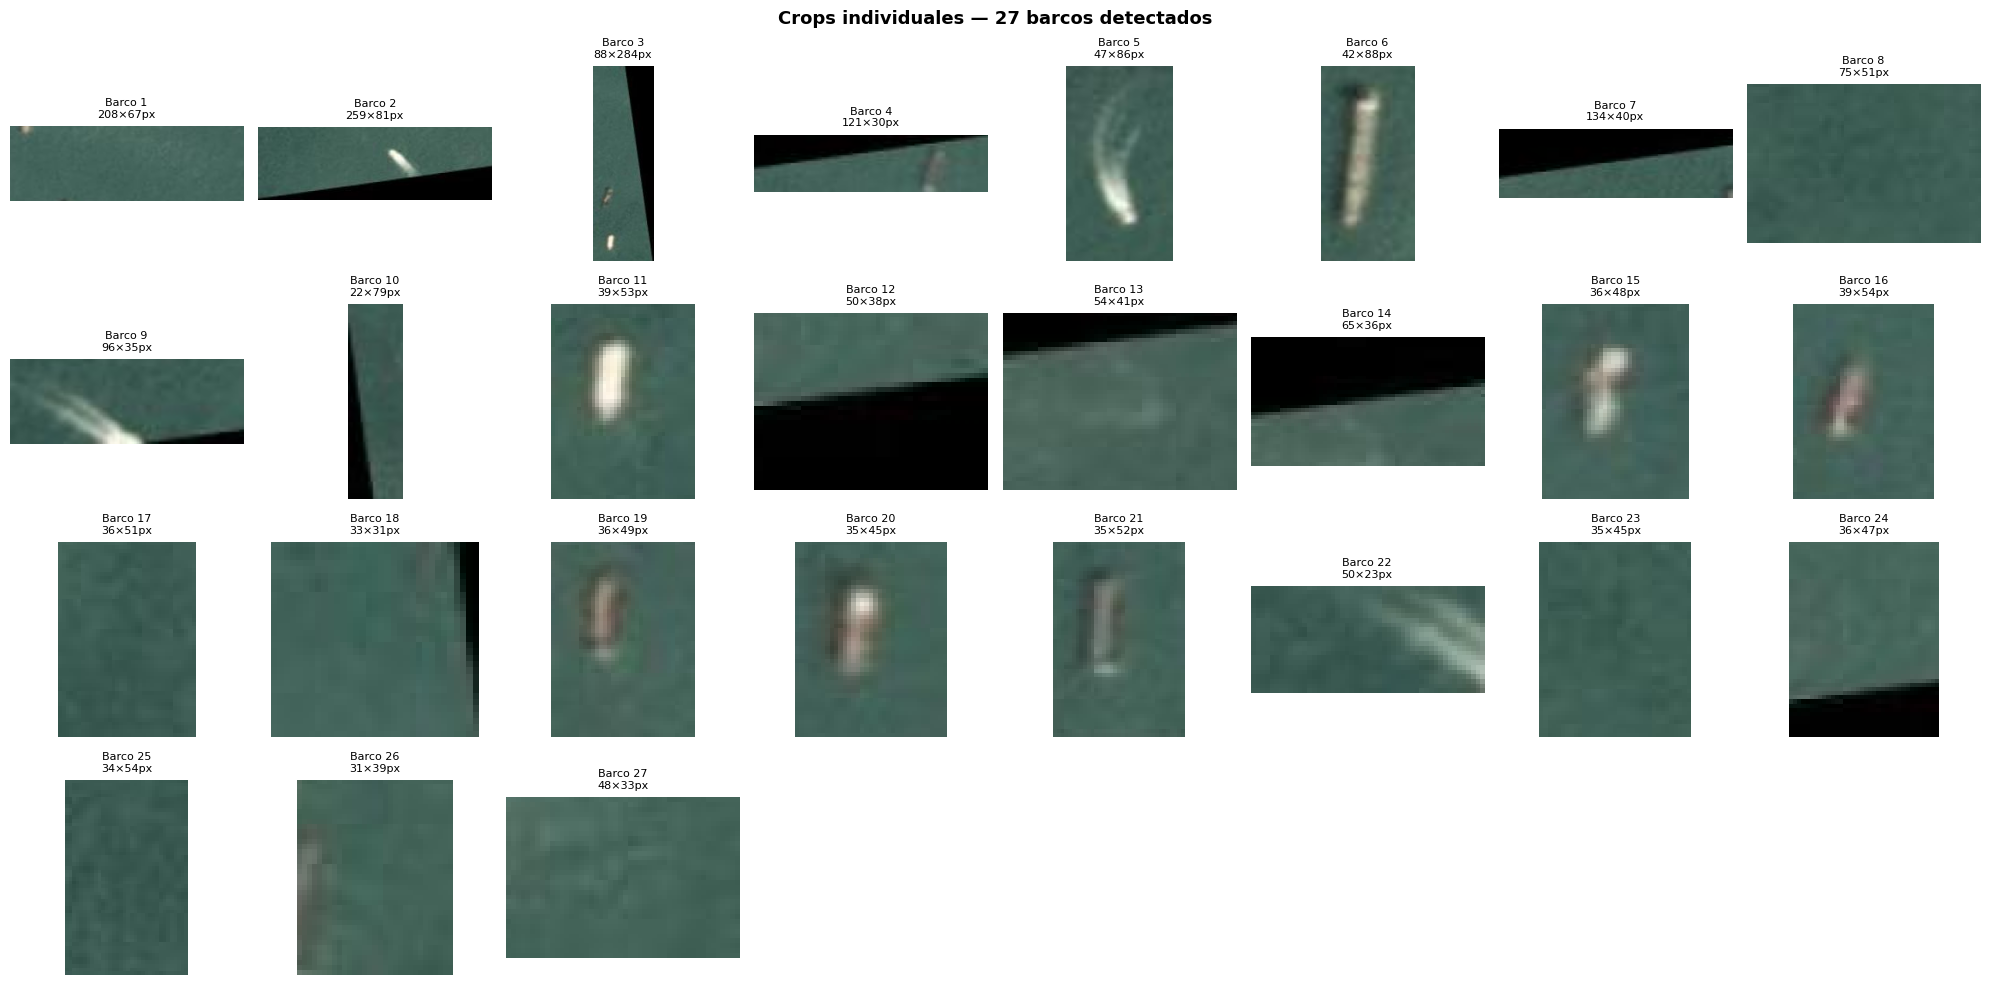

In [40]:
# ── Función de recorte con padding ────────────────────────────
def cropear_barco(img_pil, bbox, padding=12):
    x, y, w, h = bbox
    iw, ih = img_pil.size
    x1 = max(0,  x - padding)
    y1 = max(0,  y - padding)
    x2 = min(iw, x + w + padding)
    y2 = min(ih, y + h + padding)
    return img_pil.crop((x1, y1, x2, y2))

# ── Guardar crops ──────────────────────────────────────────────
PADDING = 12   #  píxeles extra alrededor de cada barco

os.makedirs('crops', exist_ok=True)
crops = []
for barco in BARCOS:
    crop = cropear_barco(imagen_pil, barco['bbox'], padding=PADDING)
    crops.append(crop)
    nombre_archivo = f"crops/barco_{barco['id']:02d}.png"
    crop.save(nombre_archivo)
    print(f"  Guardado: {nombre_archivo}  ({crop.size[0]}x{crop.size[1]} px)")

# ── Mostrar todos los crops en grilla ─────────────────────────
n = len(crops)
if n == 0:
    print('⚠️  No hay barcos. Ajustá los parámetros en la celda 6.')
else:
    cols = min(n, 8)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = np.array(axes).flatten()

    for i, (barco, crop) in enumerate(zip(BARCOS, crops)):
        axes[i].imshow(np.array(crop))
        axes[i].set_title(f"{barco['label']}\n{crop.size[0]}×{crop.size[1]}px",
                          fontsize=8)
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Crops individuales — {n} barcos detectados', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Celda 8 — Redimensionar a 80×80 para ML (Kaggle Ships dataset format)

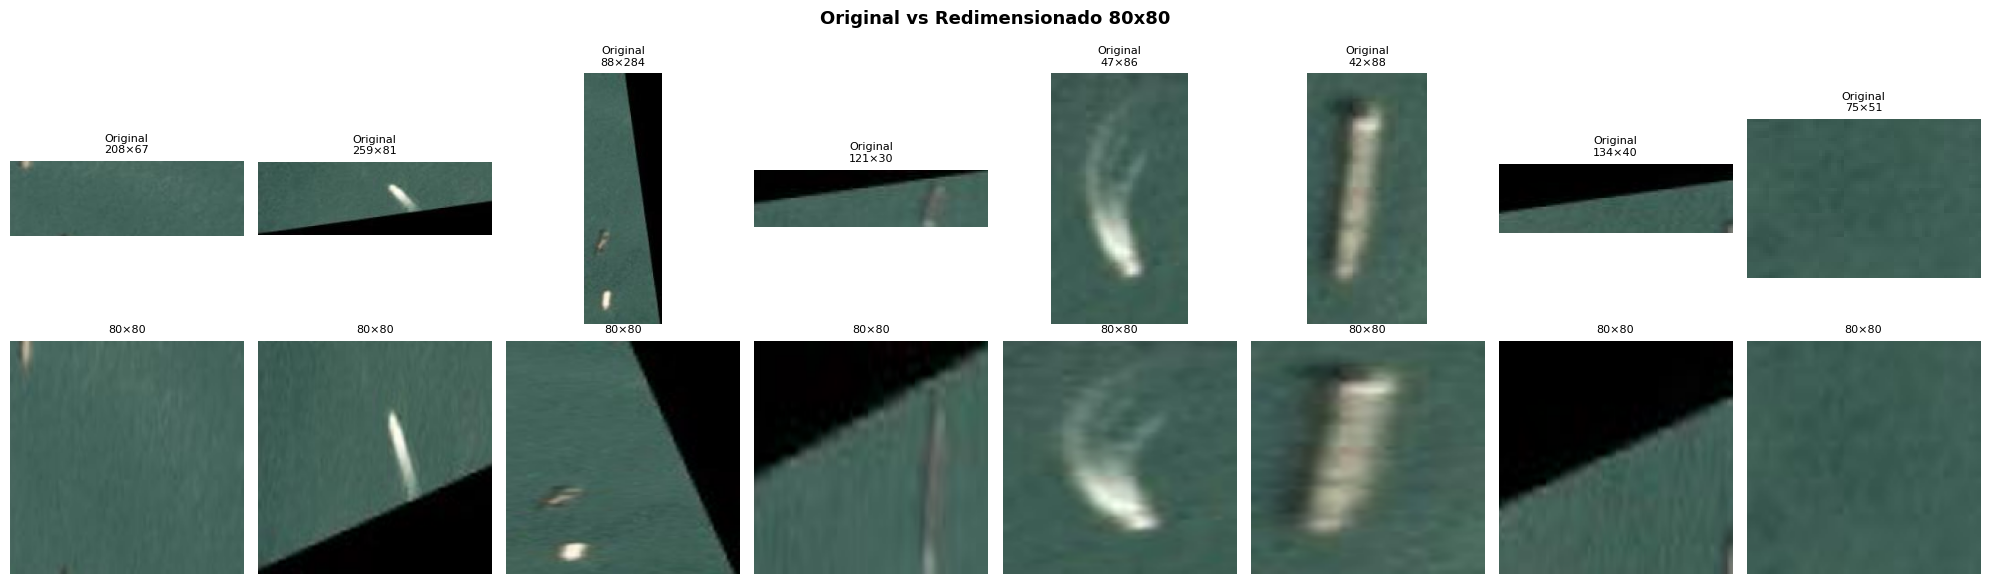


Array listo para TensorFlow/Keras:
  shape = (27, 160, 160, 3)  -> (N_barcos, alto, ancho, canales)
  dtype = uint8


In [41]:
TARGET_SIZE = (160, 160)   #   cambiá el tamaño si necesitás otro

crops_resized = []
for barco, crop in zip(BARCOS, crops):
    resized = crop.resize(TARGET_SIZE, Image.LANCZOS)
    crops_resized.append(np.array(resized))
    resized.save(f"crops/barco_{barco['id']:02d}_80x80.png")

# ── Comparación original vs 80×80 ─────────────────────────────
n    = len(crops)
cols = min(n, 8)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(2, cols, figsize=(cols * 2.5, 6))
if cols == 1:
    axes = axes.reshape(2, 1)

for i in range(cols):
    if i < n:
        axes[0, i].imshow(np.array(crops[i]))
        axes[0, i].set_title(f'Original\n{crops[i].size[0]}×{crops[i].size[1]}', fontsize=8)
        axes[0, i].axis('off')

        axes[1, i].imshow(crops_resized[i])
        axes[1, i].set_title(f'80×80', fontsize=8)
        axes[1, i].axis('off')
    else:
        axes[0, i].axis('off')
        axes[1, i].axis('off')

plt.suptitle('Original vs Redimensionado 80x80', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Array para TensorFlow/Keras ───────────────────────────────
batch = np.array(crops_resized)
print(f'\nArray listo para TensorFlow/Keras:')
print(f'  shape = {batch.shape}  -> (N_barcos, alto, ancho, canales)')
print(f'  dtype = {batch.dtype}')